# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering

---

## 1. Import packages

In [1]:
import pandas as pd

---
## 2. Load data

In [2]:
df = pd.read_csv('../data/provided/clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [3]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


---

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by your colleague to calculate the feature described above. Use this code to re-create this feature and then think about ways to build on this feature to create features with a higher predictive power.

In [4]:
price_df = pd.read_csv('../data/raw/price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [5]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


Now it is time to get creative and to conduct some of your own feature engineering! Have fun with it, explore different ideas and try to create as many as you can!

---

## Get creative — a framework for the rest of feature engineering

Estelle's feature answers one specific question. From here the brief is open-ended, so we work
through it with a repeatable framework rather than a random walk:

1. **Remove** — drop anything redundant or uninformative.
2. **Expand** — turn one column into several more useful ones (dates → durations).
3. **Combine columns** — build ratios and spreads that package a comparison.
4. **Combine datasets** — aggregate the price panel to customer level and join on `id`.
5. **Mutate** — encode categoricals, transform skewed numerics.
6. **Prune** — drop features that turn out to duplicate each other.

Every choice is grounded in a specific Task 2 EDA finding, noted inline.

### Step 1 — remove columns

The EDA found `margin_gross_pow_ele` and `margin_net_pow_ele` identical in 99.99% of rows
(correlation 0.9999). Keeping both adds collinearity for zero information, so we drop one.

In [6]:
single_value_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Columns with only 1 unique value:", single_value_cols)

identical = (df["margin_gross_pow_ele"] == df["margin_net_pow_ele"]).mean()
print(f"margin_gross_pow_ele == margin_net_pow_ele in {identical*100:.2f}% of rows -> dropping it")

df = df.drop(columns=["margin_gross_pow_ele"])

Columns with only 1 unique value: []
margin_gross_pow_ele == margin_net_pow_ele in 99.99% of rows -> dropping it


### Step 2 — expand the date columns

Raw dates aren't usable by a model. What matters for churn is **duration relative to the
snapshot** — how long they've been a client, how long until the contract ends, how recently it
was touched.

We anchor at **2016-01-01**, confirmed in the EDA as the churn snapshot (`date_renewal` tops out
at 2016-01-28, and churn is "left within 3 months of the snapshot").

We count **whole calendar months** rather than dividing days by 30.44 — the approximation drifts
by a day or two and can land a customer in the wrong month bucket.

In [7]:
from datetime import datetime

def convert_months(reference_date, dataframe, column):
    # Number of whole months between reference_date and each date in `column`
    dates = pd.to_datetime(dataframe[column])
    months = (reference_date.year - dates.dt.year) * 12 + (reference_date.month - dates.dt.month)
    # step back one month if the day-of-month hasn't been reached yet
    months -= (reference_date.day < dates.dt.day).astype(int)
    return months

reference_date = datetime(2016, 1, 1)

df["months_activ"]      = convert_months(reference_date, df, "date_activ")
df["months_to_end"]     = -convert_months(reference_date, df, "date_end")
df["months_modif_prod"] = convert_months(reference_date, df, "date_modif_prod")
df["months_renewal"]    = convert_months(reference_date, df, "date_renewal")

df = df.drop(columns=["date_activ", "date_end", "date_modif_prod", "date_renewal"])
df[["months_activ", "months_to_end", "months_modif_prod", "months_renewal"]].describe().round(1)

,months_activ,months_to_end,months_modif_prod,months_renewal
count,14606.0,14606.0,14606.0,14606.0
mean,58.6,7.4,35.5,4.8
std,19.4,3.5,30.3,3.9
min,16.0,1.0,-1.0,-1.0
25%,44.0,4.0,6.0,2.0
50%,57.0,7.0,30.0,5.0
75%,71.0,10.0,64.0,8.0
max,151.0,18.0,151.0,30.0


**A naming caution.** `months_renewal` is *months **since** the last renewal*, not months until
the next one — 93% of `date_renewal` values fall **before** the Jan 2016 snapshot, because the
column records the annual anniversary of `date_activ`. The data description's wording ("date of
the next contract renewal") is misleading. The feature is still valid; just don't read the name
as "time remaining".

In [8]:
df.groupby("churn")[["months_activ", "months_to_end", "months_modif_prod", "months_renewal"]].median()

,months_activ,months_to_end,months_modif_prod,months_renewal
churn,,,,
0,58.0,7.0,32.0,5.0
1,49.0,7.0,24.0,5.0


### Step 3 — combine columns into "better" columns

A "better" column packages a comparison the model would otherwise have to learn from two raw
columns:

* **`has_gas` → 0/1** so it's usable at all.
* **`offpeak_peak_spread`** — the gap between forecast off-peak and peak energy price, capturing
  tariff *structure* in one number (the EDA found many customers on single-period tariffs).
* **`consumption_ratio`** — last month's usage against that customer's *own* monthly average.
  Two customers with identical `cons_last_month` can be trending in opposite directions.
* **`margin_per_product`** — profitability per product held, rather than total margin (which is
  partly just a function of owning more products).

In [9]:
df["has_gas"] = df["has_gas"].map({"t": 1, "f": 0})

df["offpeak_peak_spread"] = df["forecast_price_energy_off_peak"] - df["forecast_price_energy_peak"]
df["consumption_ratio"]   = (df["cons_last_month"] / (df["cons_12m"] / 12).replace(0, pd.NA)).fillna(0)
df["margin_per_product"]  = df["net_margin"] / df["nb_prod_act"]

df[["has_gas", "offpeak_peak_spread", "consumption_ratio", "margin_per_product"]].describe().round(3)

,has_gas,offpeak_peak_spread,margin_per_product
count,14606.000,14606.000,14606.000
mean,0.182,0.087,161.513
std,0.385,0.062,225.147
min,0.000,0.000,0.000
25%,0.000,0.016,41.745
50%,0.000,0.079,95.075
75%,0.000,0.145,205.770
max,1.000,0.274,10203.500


### Step 4 — combine the datasets

`price_data.csv` is a monthly panel; it must be **aggregated to one row per customer** before it
can join `df` on `id`, or every client row gets multiplied by its months of price history.

Estelle's Dec-minus-Jan feature is one such aggregation. Rather than stopping at one idea, we
enumerate the space systematically — **every period pair × (var, fix) × (mean, max)**:

* **Mean price differences across periods** — the average gap between off-peak/peak/mid-peak.
* **Max monthly price differences** — the *largest* gap any single month produced. A customer
  reacts to one shocking bill, not to an annual average, so the max is a sharper churn signal
  than the mean.
* **Off-peak volatility** (`std`) — the EDA found churners and retained customers pay almost the
  same *average* price, but differ in how much it moved.

In [10]:
price_var_cols = ["price_off_peak_var", "price_peak_var", "price_mid_peak_var"]
price_fix_cols = ["price_off_peak_fix", "price_peak_fix", "price_mid_peak_fix"]
period_pairs   = [("off_peak", "peak"), ("peak", "mid_peak"), ("off_peak", "mid_peak")]

# --- mean price differences across periods (whole year) ---
mean_prices = price_df.groupby("id")[price_var_cols + price_fix_cols].mean().reset_index()
for a, b in period_pairs:
    mean_prices[f"{a}_{b}_var_mean_diff"] = mean_prices[f"price_{a}_var"] - mean_prices[f"price_{b}_var"]
    mean_prices[f"{a}_{b}_fix_mean_diff"] = mean_prices[f"price_{a}_fix"] - mean_prices[f"price_{b}_fix"]
mean_diff_cols = [c for c in mean_prices.columns if c.endswith("_mean_diff")]

# --- max monthly price difference across periods ---
by_month = price_df.groupby(["id", "price_date"])[price_var_cols + price_fix_cols].mean().reset_index()
for a, b in period_pairs:
    by_month[f"{a}_{b}_var_d"] = by_month[f"price_{a}_var"] - by_month[f"price_{b}_var"]
    by_month[f"{a}_{b}_fix_d"] = by_month[f"price_{a}_fix"] - by_month[f"price_{b}_fix"]
d_cols = [c for c in by_month.columns if c.endswith("_d")]
max_diff = by_month.groupby("id")[d_cols].max().reset_index()
max_diff.columns = ["id"] + [c[:-2] + "_max_monthly_diff" for c in d_cols]

# --- price level and volatility ---
price_features = price_df.groupby("id").agg(
    mean_offpeak_energy=("price_off_peak_var", "mean"),
    std_offpeak_energy=("price_off_peak_var", "std"),
    mean_peak_energy=("price_peak_var", "mean"),
).reset_index()
price_features["std_offpeak_energy"] = price_features["std_offpeak_energy"].fillna(0)

print(f"Each price table is one row per customer: "
      f"{mean_prices.shape[0]:,} / {max_diff.shape[0]:,} / {price_features.shape[0]:,}")

Each price table is one row per customer: 16,096 / 16,096 / 16,096


In [11]:
rows_before = df.shape[0]
for table in [diff, mean_prices[["id"] + mean_diff_cols], max_diff, price_features]:
    df = df.merge(table, on="id", how="left")

print(f"rows before merges: {rows_before:,}  ->  after: {df.shape[0]:,}  (must be unchanged)")
print(f"columns now: {df.shape[1]}")

rows before merges: 14,606  ->  after: 14,606  (must be unchanged)
columns now: 63


### Step 5 — mutate: encode categoricals, transform skewed numerics

* **Rare categories.** `channel_sales` and `origin_up` have levels with only 1–11 customers and
  0% churn purely from tiny sample size. We fold anything under 50 customers into `"other"`
  before one-hot encoding, so those customers keep a flag rather than vanishing.
* **Skewed numerics.** The EDA found skew of 4–37 across the consumption/margin columns. We apply
  `log1p` — the `1p` matters because several columns are legitimately zero (structural, not
  missing) and `log(0)` is undefined.

**Only positively skewed columns are transformed.** Log-transforming a symmetric or
left-skewed column makes it *worse*, so the price-forecast columns are deliberately excluded —
the check below confirms which columns qualify.

In [12]:
for col in ["channel_sales", "origin_up"]:
    counts = df[col].value_counts()
    rare = counts[counts < 50].index
    df[col] = df[col].where(~df[col].isin(rare), "other")
    print(col, "-> levels kept:", df[col].value_counts().to_dict())

df = pd.get_dummies(df, columns=["channel_sales", "origin_up"], prefix=["channel", "origin"], dtype=int)

channel_sales -> levels kept: {'foosdfpfkusacimwkcsosbicdxkicaua': 6754, 'MISSING': 3725, 'lmkebamcaaclubfxadlmueccxoimlema': 1843, 'usilxuppasemubllopkaafesmlibmsdf': 1375, 'ewpakwlliwisiwduibdlfmalxowmwpci': 893, 'other': 16}
origin_up -> levels kept: {'lxidpiddsbxsbosboudacockeimpuepw': 7097, 'kamkkxfxxuwbdslkwifmmcsiusiuosws': 4294, 'ldkssxwpmemidmecebumciepifcamkci': 3148, 'MISSING': 64, 'other': 3}


In [13]:
import numpy as np

skewed_cols = [
    "cons_12m", "cons_gas_12m", "cons_last_month", "imp_cons",
    "forecast_cons_12m", "forecast_cons_year", "forecast_meter_rent_12m",
    "net_margin", "margin_net_pow_ele", "pow_max",
]

# Verify each column is positively skewed AND that log1p actually improves it
print(f"{'column':<28}{'skew before':>13}{'skew after':>12}")
for col in skewed_cols:
    before, after = df[col].skew(), np.log1p(df[col]).skew()
    flag = "  <-- would worsen" if abs(after) > abs(before) else ""
    print(f"{col:<28}{before:>13.2f}{after:>12.2f}{flag}")

df[skewed_cols] = np.log1p(df[skewed_cols])

column                        skew before  skew after
cons_12m                             6.00       -0.38
cons_gas_12m                         9.60        1.88
cons_last_month                      6.39       -0.19
imp_cons                            13.20        0.01
forecast_cons_12m                    7.16       -2.03
forecast_cons_year                  16.59       -0.12
forecast_meter_rent_12m              1.51       -0.60
net_margin                          36.57       -0.97
margin_net_pow_ele                   4.47       -1.31
pow_max                              5.79        1.80


Note we **overwrite** rather than keeping raw and log side by side. During exploration you might
keep both, but a raw column and its log are monotonically related — carrying both into a model
just adds a perfectly redundant pair, which the correlation step below would flag anyway.

### Step 6 — prune redundant features with a correlation check

Feature engineering is iterative: we deliberately generated more features than we need, and now
remove the ones that duplicate each other. Highly correlated predictors don't add information —
they split importance between themselves and destabilise linear models.

**The rule:** for each pair correlating above 0.95, drop whichever member has the *weaker*
correlation with `churn`. That's a principled tie-break — keep the more predictive one — rather
than dropping arbitrarily by column order.

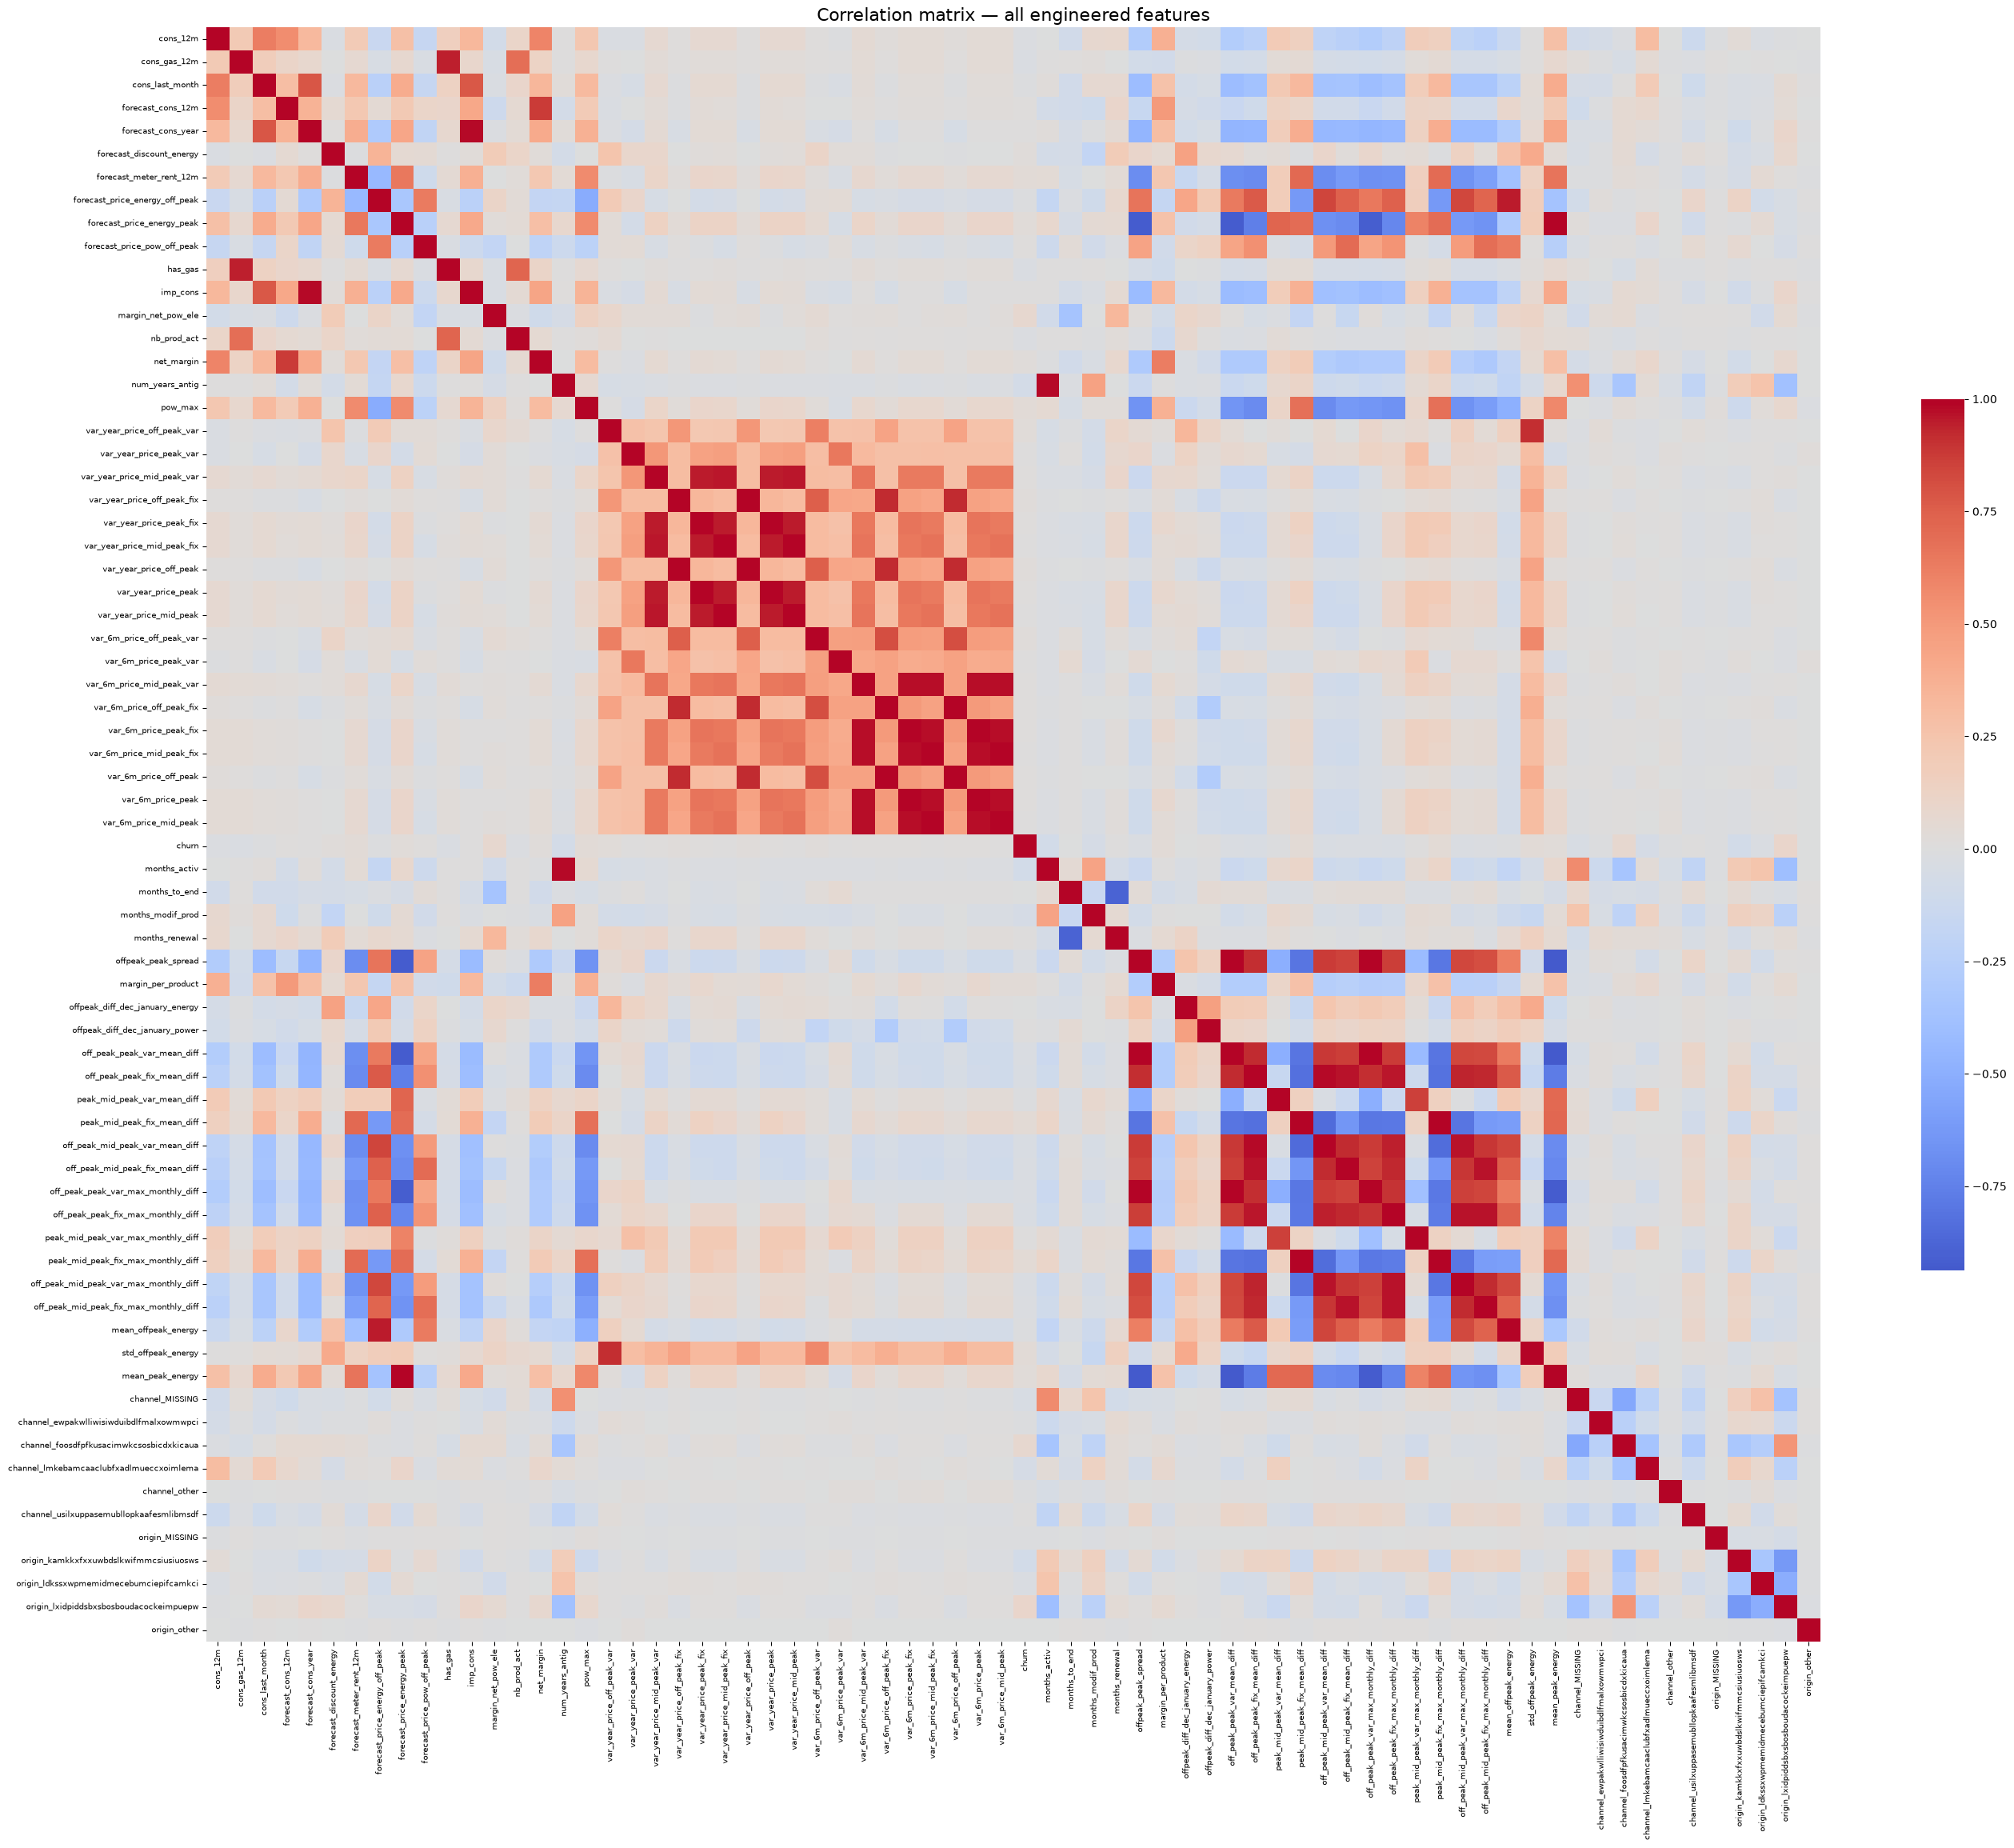

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

correlation = df.drop(columns=["id"]).corr(numeric_only=True)

plt.figure(figsize=(28, 24))
sns.heatmap(correlation, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.5}, xticklabels=True, yticklabels=True)
plt.xticks(fontsize=7); plt.yticks(fontsize=7)
plt.title("Correlation matrix — all engineered features", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
abs_corr    = correlation.abs()
churn_corr  = abs_corr["churn"]
feature_cols = [c for c in abs_corr.columns if c != "churn"]

pairwise = abs_corr.loc[feature_cols, feature_cols]
upper = pairwise.where(np.triu(np.ones(pairwise.shape), k=1).astype(bool)).stack()
high_pairs = upper[upper > 0.95].sort_values(ascending=False)

to_drop = set()
for (col_a, col_b), value in high_pairs.items():
    if col_a in to_drop or col_b in to_drop:
        continue
    to_drop.add(col_a if churn_corr[col_a] < churn_corr[col_b] else col_b)

print(f"{len(high_pairs)} feature pairs correlate above 0.95 -> dropping {len(to_drop)} columns\n")
for (col_a, col_b), value in high_pairs.head(12).items():
    loser = col_a if churn_corr[col_a] < churn_corr[col_b] else col_b
    print(f"  {value:.4f}  {col_a}  <->  {col_b}   (drop: {loser})")

35 feature pairs correlate above 0.95 -> dropping 21 columns

  1.0000  var_6m_price_mid_peak_fix  <->  var_6m_price_mid_peak   (drop: var_6m_price_mid_peak_fix)
  1.0000  var_year_price_mid_peak_fix  <->  var_year_price_mid_peak   (drop: var_year_price_mid_peak_fix)
  1.0000  var_6m_price_off_peak_fix  <->  var_6m_price_off_peak   (drop: var_6m_price_off_peak_fix)
  1.0000  var_year_price_peak_fix  <->  var_year_price_peak   (drop: var_year_price_peak)
  1.0000  var_6m_price_peak_fix  <->  var_6m_price_peak   (drop: var_6m_price_peak_fix)
  1.0000  var_year_price_off_peak_fix  <->  var_year_price_off_peak   (drop: var_year_price_off_peak_fix)
  0.9966  peak_mid_peak_fix_mean_diff  <->  peak_mid_peak_fix_max_monthly_diff   (drop: peak_mid_peak_fix_max_monthly_diff)
  0.9940  forecast_price_energy_peak  <->  mean_peak_energy   (drop: forecast_price_energy_peak)
  0.9914  offpeak_peak_spread  <->  off_peak_peak_var_mean_diff   (drop: off_peak_peak_var_mean_diff)
  0.9913  off_peak_peak_v

In [16]:
df = df.drop(columns=sorted(to_drop))
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Final shape: 14,606 rows x 51 columns


**What the pruning revealed**

* Six pairs correlate at **1.0000** — the `var_year_price_*_fix` / `var_year_price_*` columns
  already present in `clean_data_after_eda.csv`. The combined columns are numerically dominated
  by their fixed-price component, because fixed prices (~€43) dwarf variable prices (~€0.14).
  That is the scale-mixing trap the EDA warned about, showing up in someone else's cleaning.
* Our hand-built `offpeak_peak_spread` correlates **0.99** with the systematically generated
  `off_peak_peak_var_mean_diff` — they measure the same thing. Worth noting: the tie-break kept
  ours, because it correlates marginally more strongly with churn.
* `num_years_antig` correlates **0.98** with `months_activ`, so one goes.

The lesson: generating features broadly and *then* pruning on evidence beats trying to guess the
right feature set up front.

### Final feature set

In [17]:
df.head(3)

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_pow_off_peak,...,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_other,channel_usilxuppasemubllopkaafesmlibmsdf,origin_MISSING,origin_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_ldkssxwpmemidmecebumciepifcamkci,origin_lxidpiddsbxsbosboudacockeimpuepw,origin_other
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,10.914124,0.0,0.000000,0.0,0.0,1.022451,0.114481,40.606701,...,0,1,0,0,0,0,0,0,1,0
1,d29c2c54acc38ff3c0614d0a653813dd,8.446985,0.000000,0.0,5.252012,0.0,0.0,2.848971,0.145711,44.311378,...,0,0,0,0,0,0,1,0,0,0
2,764c75f661154dac3a6c254cd082ea7d,6.300786,0.000000,0.0,3.891004,0.0,0.0,3.681855,0.165794,44.311378,...,0,1,0,0,0,0,1,0,0,0


In [18]:
df.to_csv("../outputs/clean_data_after_eda_engineered.csv", index=False)
print("Saved: clean_data_after_eda_engineered.csv")

Saved: clean_data_after_eda_engineered.csv
